In [10]:

# Install necessary libraries




import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms, datasets
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [11]:
# Set environment variable for number of workers
os.environ["NUM_WORKERS"] = "4"

In [12]:
# @title Define Parameters { run: "auto" }

# Global Parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", 4)) # Use environment variable
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 18
WEIGHT_DECAY = 1e-5

# Path to your dataset
dataset_path = "Data" 

# Class names (MUST match your folder names exactly)
label_names = ["Mild Dementia", "Moderate Dementia", "Non Dementia", "Very Mild Dementia"]
NUM_CLASSES = len(label_names)

print(f"Device set to: {DEVICE} 🚀")
print(f"Dataset path: {dataset_path}")
print(f"Number of classes: {NUM_CLASSES} ({label_names})")

Device set to: cuda 🚀
Dataset path: Data
Number of classes: 4 (['Mild Dementia', 'Moderate Dementia', 'Non Dementia', 'Very Mild Dementia'])


In [13]:
## 3. Data Augmentation, Loading, and Splitting

Since the dataset is not pre-split into `train` and `test` folders, we will load all images from the `Data` folder and perform a code-based **70% Train, 15% Validation, 15% Test** split.

SyntaxError: invalid syntax (4045559857.py, line 3)

In [14]:
# A helper class to apply transforms to a subset from the random_split function
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        # subset[index] returns (PIL Image, class_index)
        x_pil, y = self.subset[index]
        
        # Convert PIL Image to numpy array (required for Albumentations)
        x = np.array(x_pil)
        
        if self.transform:
            x = self.transform(image=x)['image']
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. Define Augmentation (Train Transform)
# Apply random augmentations to the training data
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.VerticalFlip(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

# 2. Define Validation/Test Transform (No Augmentation, just standardization and resize)
val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)
print("✅ Transforms defined successfully.")

✅ Transforms defined successfully.


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [15]:
# Check dataset exists
assert os.path.exists(dataset_path), f"❌ Dataset path not found: {dataset_path}"

# 1. Load the entire dataset *without* any transforms yet
full_dataset_no_transform = datasets.ImageFolder(dataset_path, transform=None)
total_size = len(full_dataset_no_transform)
print(f"✅ Full dataset found with {total_size} images.")

# 2. Define split sizes (70% train, 15% validation, 15% test)
train_size = int(total_size * 0.70)
val_size = int(total_size * 0.15)
test_size = total_size - train_size - val_size # Use remainder for test set

print(f"\nSplitting full dataset into:")
print(f" ┣━ Train: {train_size} images (70%)")
print(f" ┣━ Validation: {val_size} images (15%)")
print(f" ┗━ Test: {test_size} images (15%)")

# 3. Split the dataset using a fixed seed for reproducibility
train_subset, val_subset, test_subset = random_split(
    full_dataset_no_transform, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) 
)

# 4. Apply the correct transforms to each split using the helper class
train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)
test_dataset = TransformedDataset(test_subset, transform=val_transform) 

# 5. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders created with batch size {BATCH_SIZE}.")

# 6. Set class mapping for later use
class_to_idx = full_dataset_no_transform.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

✅ Full dataset found with 86437 images.

Splitting full dataset into:
 ┣━ Train: 60505 images (70%)
 ┣━ Validation: 12965 images (15%)
 ┗━ Test: 12967 images (15%)

DataLoaders created with batch size 32.


In [ ]:
## 5. Model Definition (ResNet18)

In [16]:
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()
        
        # Load pre-trained ResNet18 model
        self.model = models.resnet18(weights='IMAGENET1K_V1')
        
        # Freeze all layers in the base model
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Get the number of features in the last layer
        num_ftrs = self.model.fc.in_features
        
        # Replace the last layer with a new one for our number of classes
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Unfreeze the new classification layers
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

model = AlzheimerModel(NUM_CLASSES).to(DEVICE)
# Print the model architecture to verify the new last layer
# from torchinfo import summary
# summary(model, input_size=(BATCH_SIZE, 3, 224, 224), device=DEVICE)

print("✅ Model loaded and configured for transfer learning.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/zeus/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 443MB/s]


✅ Model loaded and configured for transfer learning.


In [ ]:
## 6. Training Functions

In [17]:
def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, desc="Training")
    total_loss = 0
    
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        
        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)
        
        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(loader)

def val_fn(loader, model, loss_fn):
    model.eval()
    loop = tqdm(loader, desc="Validation")
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in loop:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            
            predictions = model(data)
            loss = loss_fn(predictions, targets)
            total_loss += loss.item()
            
            # Save predictions and targets for metric calculation
            _, predicted_classes = predictions.max(1)
            all_preds.extend(predicted_classes.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    avg_loss = total_loss / len(loader)
    
    # Calculate F1-score
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, f1

In [ ]:
## 7. Training Loop

In [18]:
# Initialize loss function, optimizer, and scaler for mixed precision training
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler()
# FIX: Removed 'verbose=True' argument which is not supported in older PyTorch versions
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

best_val_f1 = 0
train_losses = []
val_losses = []
val_f1_scores = []

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    
    # Training
    train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
    train_losses.append(train_loss)
    
    # Validation
    val_loss, val_f1 = val_fn(val_loader, model, loss_fn)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    
    # Step scheduler
    scheduler.step(val_f1)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Score: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "epoch": epoch
        }
        torch.save(checkpoint, "best_model.pth.tar")
        print("✅ New best model saved!")

print("\nTraining complete!")
print(f"Best Validation F1-Score: {best_val_f1:.4f}")

/tmp/ipykernel_45236/3529222014.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting training...

--- Epoch 1/18 ---


Training:   0%|          | 0/1891 [00:00<?, ?it/s]/tmp/ipykernel_45236/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 406/406 [00:05<00:00, 75.95it/s]


Train Loss: 0.5876 | Val Loss: 0.5297 | Val F1-Score: 0.7079
✅ New best model saved!

--- Epoch 2/18 ---


Training:   0%|          | 0/1891 [00:00<?, ?it/s]/tmp/ipykernel_45236/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 406/406 [00:04<00:00, 81.50it/s]


...

Train Loss: 0.4043 | Val Loss: 0.3239 | Val F1-Score: 0.8694
✅ New best model saved!

--- Epoch 17/18 ---


Training:   0%|          | 0/1891 [00:00<?, ?it/s]/tmp/ipykernel_45236/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 406/406 [00:05<00:00, 79.57it/s]


Train Loss: 0.4014 | Val Loss: 0.3130 | Val F1-Score: 0.8722
✅ New best model saved!

--- Epoch 18/18 ---


Training:   0%|          | 0/1891 [00:00<?, ?it/s]/tmp/ipykernel_45236/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 406/406 [00:05<00:00, 80.82it/s]

Train Loss: 0.3968 | Val Loss: 0.3139 | Val F1-Score: 0.8659

Training complete!
Best Validation F1-Score: 0.8722


In [ ]:
## 8. Evaluation on Test Set

We will now evaluate the best saved model on the dedicated **Test Set** (15% of the total data) to get a final, unbiased performance metric.

In [20]:
def check_accuracy(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            scores = model(x)
            _, predictions = scores.max(1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    return all_targets, all_preds

# Load the best model
try:
    checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']} with F1: {checkpoint['best_val_f1']:.4f}")
except FileNotFoundError:
    print("WARNING: best_model.pth.tar not found. Using current model state for testing.")

# Run evaluation on the test set
test_targets, test_preds = check_accuracy(test_loader, model)

# Generate Classification Report
print("\n--- Final Test Set Classification Report ---")
print(classification_report(test_targets, test_preds, target_names=label_names, digits=4))

Loaded best model from epoch 16 with F1: 0.8722


Testing:   4%|▍         | 18/406 [00:00<00:06, 59.62it/s]

Testing: 100%|██████████| 406/406 [00:05<00:00, 71.93it/s]


--- Final Test Set Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia     0.7231    0.5526    0.6264       742
 Moderate Dementia     0.9667    0.3537    0.5179        82
      Non Dementia     0.9068    0.9561    0.9308     10061
Very Mild Dementia     0.7270    0.6153    0.6665      2082

          accuracy                         0.8745     12967
         macro avg     0.8309    0.6194    0.6854     12967
      weighted avg     0.8678    0.8745    0.8683     12967



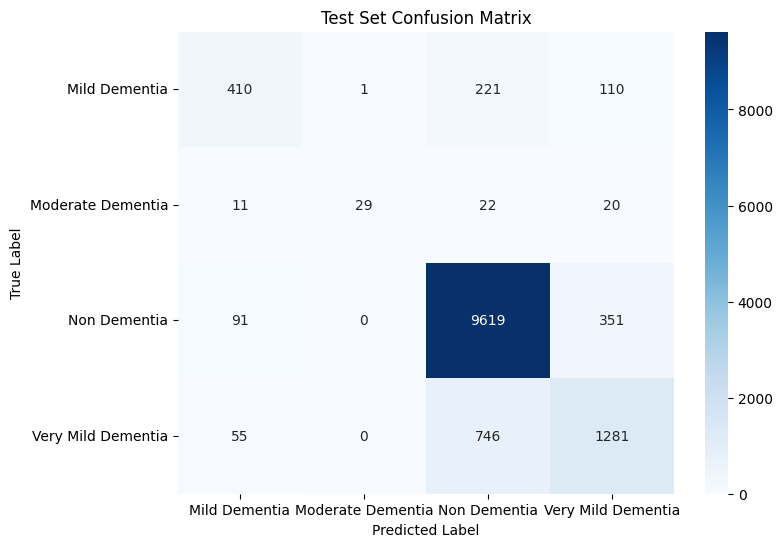

In [21]:
# Confusion Matrix Visualization
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()